In [1]:
# 气候数据可视化复现
# 复现以下图表：
# 1. 01_global_temperature_trend.png - 全球温度趋势
# 2. 01_temperature_bands.png - 温度带图
# 3. 02_country_heatmap_pro.png - 国家热力图
# 4. 06_temperature_change_rate.png - 温度变化速率
# 5. 04_latitude_violin.png - 纬度小提琴图
# 6. 05_temperature_distribution.png - 温度分布
# 7. 12_decade_comparison.png - 年代对比

# 在notebook中显示图表
%matplotlib inline

import sys
import os
sys.path.append('../code')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# 设置中文字体
MAC_CHINESE_FONTS = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['font.sans-serif'] = MAC_CHINESE_FONTS + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 设置Seaborn风格
sns.set_theme(style="ticks", context="talk")

# 数据路径
DATA_DIR = Path('../data/raw')
OUTPUT_DIR = Path('../output/notebook_figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 是否保存图片（设为False时只显示不保存）
SAVE_FIGURES = False

print("✓ 环境设置完成")
print(f"✓ 数据目录: {DATA_DIR}")
print(f"✓ 输出目录: {OUTPUT_DIR}")
print(f"✓ 保存图片: {'是' if SAVE_FIGURES else '否（仅显示）'}")


✓ 环境设置完成
✓ 数据目录: ../data/raw
✓ 输出目录: ../output/notebook_figures
✓ 保存图片: 否（仅显示）


In [2]:
# 加载数据
from data_loader import ClimateDataLoader

loader = ClimateDataLoader(data_dir=str(DATA_DIR))

print("正在加载数据...")
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=True)

print("\n✓ 数据加载完成")
print(f"  全球温度: {len(df_global):,} 条记录")
print(f"  国家温度: {len(df_country):,} 条记录")
print(f"  城市温度: {len(df_city):,} 条记录")


正在加载数据...
正在加载全球温度数据: ../data/raw/GlobalTemperatures.csv
✓ 加载完成：3192 条记录
正在加载国家温度数据: ../data/raw/GlobalLandTemperaturesByCountry.csv
✓ 加载完成：577462 条记录
  国家数量: 243
正在加载主要城市温度数据: ../data/raw/GlobalLandTemperaturesByMajorCity.csv
✓ 加载完成：239177 条记录
  城市数量: 100
  国家数量: 49

✓ 数据加载完成
  全球温度: 3,192 条记录
  国家温度: 577,462 条记录
  城市温度: 239,177 条记录


📊 Plotting Figure 1-1: Global Land Average Temperature Long-term Trend...


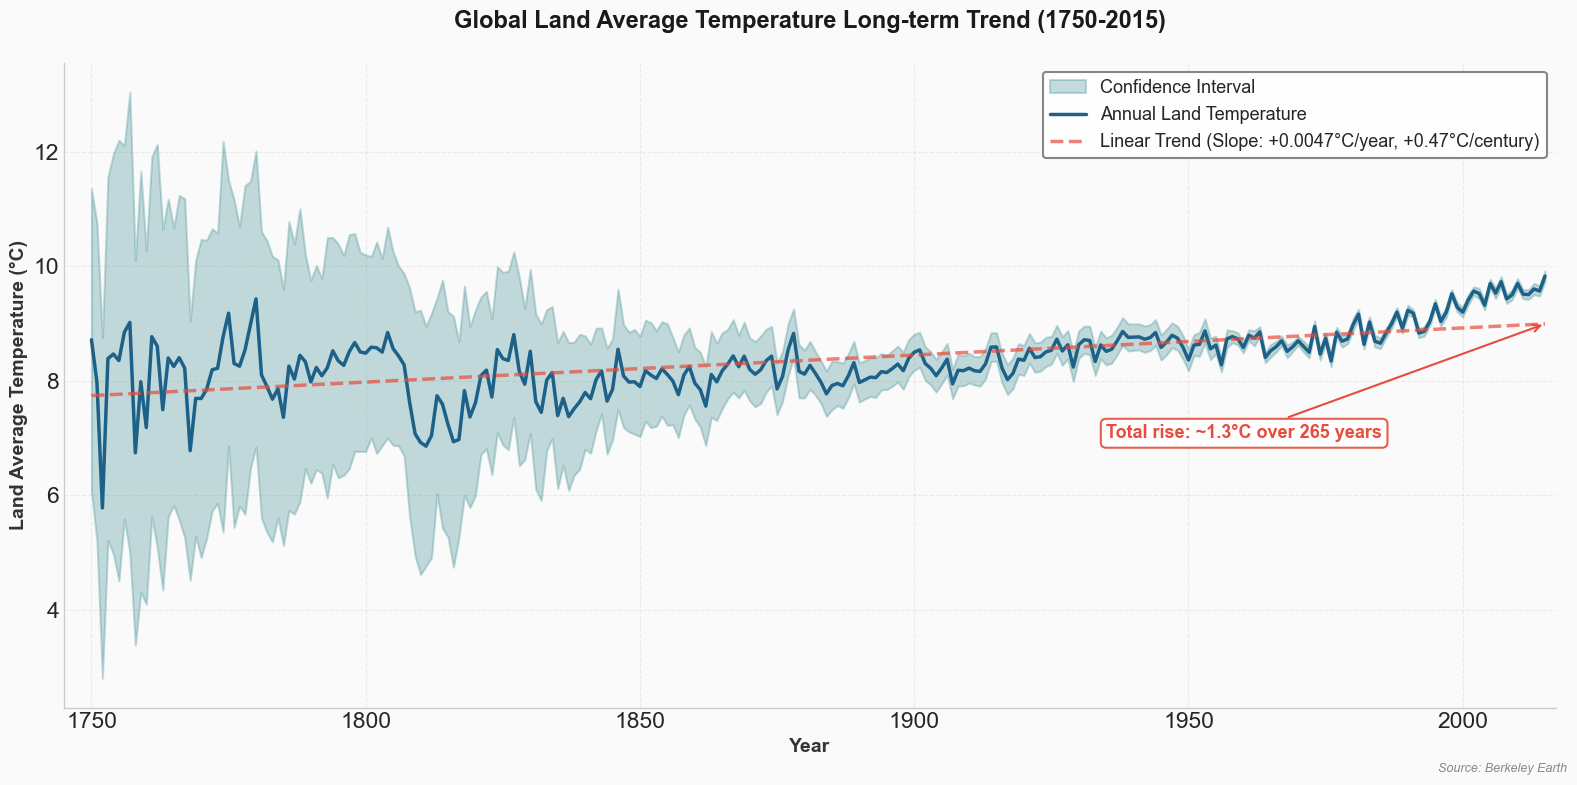


📈 Key Findings:
   Trend slope: +0.0047°C/year
   Equivalent: +0.47°C/century
   Total temperature rise over 265 years: ~1.3°C


In [ ]:
# Figure 1-1: Global Land Average Temperature Long-term Trend
# Purpose: Answer the fundamental question "Is the Earth getting warmer?"
# Use full time-series (265 years) linear regression to mathematically prove warming trend

print("📊 Plotting Figure 1-1: Global Land Average Temperature Long-term Trend...")

# Aggregate data by year
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index()
df_yearly = df_yearly.dropna()

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Get crest color palette
crest_colors = sns.color_palette("crest", n_colors=10)
main_color = crest_colors[7]      # Deep teal for main line
fill_color = crest_colors[4]      # Medium teal for confidence band
trend_color = '#E74C3C'           # Red for trend line

# 1. Plot confidence interval (shaded band)
ax.fill_between(
    df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.3, color=fill_color, label='Confidence Interval', zorder=1
)

# 2. Plot main temperature curve
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
        linewidth=2.5, color=main_color, label='Annual Land Temperature', zorder=2)

# 3. Calculate and plot full time-series (265 years) linear regression trend line
z = np.polyfit(df_yearly['year'], df_yearly['LandAverageTemperature'], 1)
p = np.poly1d(z)
slope_per_year = z[0]
slope_per_century = z[0] * 100

# Trend line with red color and reduced opacity
ax.plot(df_yearly['year'], p(df_yearly['year']), 
        linestyle='--', linewidth=2.5, color=trend_color, alpha=0.7,
        label=f'Linear Trend (Slope: +{slope_per_year:.4f}°C/year, +{slope_per_century:.2f}°C/century)', 
        zorder=3)

# 4. Add annotation for trend line information - moved to below, larger font
start_year = df_yearly['year'].min()
end_year = df_yearly['year'].max()
start_temp = p(start_year)
end_temp = p(end_year)
temp_rise = end_temp - start_temp

ax.annotate(
    f'Total rise: ~{temp_rise:.1f}°C over 265 years',
    xy=(end_year, end_temp),
    xytext=(end_year - 80, end_temp - 2.0),  # Moved to below
    fontsize=13, color=trend_color, fontweight='bold',  # Larger font
    arrowprops=dict(arrowstyle='->', color=trend_color, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=trend_color, alpha=0.9)
)

# 5. Set axis labels and title
ax.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('Land Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('Global Land Average Temperature Long-term Trend (1750-2015)', 
             fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')

# 6. Set legend - moved to upper right, larger font
legend = ax.legend(fontsize=13, frameon=True, fancybox=True, 
                   framealpha=0.95, edgecolor='gray', loc='upper right')

# 7. Set grid and style
ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')

# 8. Set x-axis range
ax.set_xlim(df_yearly['year'].min() - 5, df_yearly['year'].max() + 2)

# 9. Add data source footnote
fig.text(0.99, 0.01, 'Source: Berkeley Earth', 
         fontsize=9, color='#888888', ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.show()

# Save figure
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / '01_global_temperature_trend.png', 
                dpi=300, bbox_inches='tight', facecolor='#fafafa', edgecolor='none')
    print("✓ Saved: 01_global_temperature_trend.png")

print(f"\n📈 Key Findings:")
print(f"   Trend slope: +{slope_per_year:.4f}°C/year")
print(f"   Equivalent: +{slope_per_century:.2f}°C/century")
print(f"   Total temperature rise over 265 years: ~{temp_rise:.1f}°C")

📊 Plotting Figure 1-2: Temperature Bands (Confidence Interval Visualization)...


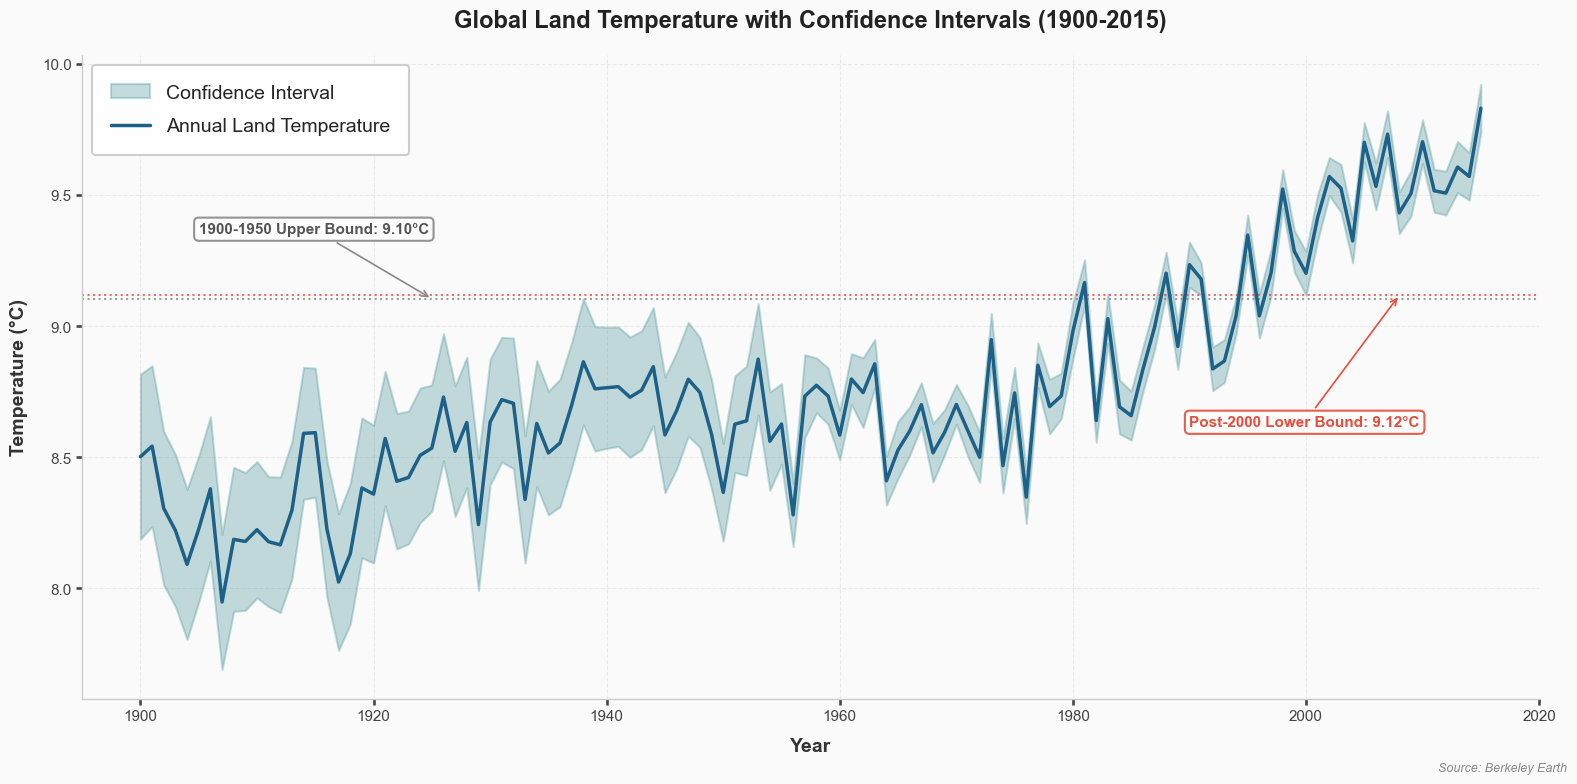

In [32]:
# Figure 1-2: Temperature Bands (Confidence Interval Visualization)
# Focus on 1900-2015, single confidence interval

print("📊 Plotting Figure 1-2: Temperature Bands (Confidence Interval Visualization)...")

# Aggregate data by year
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index()
df_yearly = df_yearly.dropna()

# Filter to focus period: 1900-2015
df_focus = df_yearly[df_yearly['year'] >= 1900]

# Create figure
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Get crest color palette
crest_colors = sns.color_palette("crest", n_colors=10)
main_color = crest_colors[7]
fill_color = crest_colors[4]

# 1. Plot single confidence interval
ax.fill_between(
    df_focus['year'],
    df_focus['LandAverageTemperature'] - df_focus['LandAverageTemperatureUncertainty'],
    df_focus['LandAverageTemperature'] + df_focus['LandAverageTemperatureUncertainty'],
    alpha=0.3, color=fill_color, label='Confidence Interval', zorder=1
)

# 2. Plot main temperature line
ax.plot(df_focus['year'], df_focus['LandAverageTemperature'],
        linewidth=2.5, color=main_color, label='Annual Land Temperature', zorder=3)

# 3. Calculate key statistics
early_20th = df_focus[(df_focus['year'] >= 1900) & (df_focus['year'] < 1950)]
early_upper = (early_20th['LandAverageTemperature'] + early_20th['LandAverageTemperatureUncertainty']).max()

post_2000 = df_focus[df_focus['year'] >= 2000]
post_2000_lower = (post_2000['LandAverageTemperature'] - post_2000['LandAverageTemperatureUncertainty']).min()

# Draw horizontal reference lines
ax.axhline(y=early_upper, color='#888888', linewidth=1.5, linestyle=':', alpha=0.8, zorder=2)
ax.axhline(y=post_2000_lower, color='#E74C3C', linewidth=1.5, linestyle=':', alpha=0.8, zorder=2)

# Annotations
ax.annotate(
    f'1900-1950 Upper Bound: {early_upper:.2f}°C',
    xy=(1925, early_upper),
    xytext=(1905, early_upper + 0.25),
    fontsize=11, color='#555555', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#888888', alpha=0.9)
)

ax.annotate(
    f'Post-2000 Lower Bound: {post_2000_lower:.2f}°C',
    xy=(2008, post_2000_lower),
    xytext=(1990, post_2000_lower - 0.5),  # Moved right and down
    fontsize=11, color='#E74C3C', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#E74C3C', alpha=0.9)
)

# 4. Set axis labels and title
ax.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333', labelpad=10)
ax.set_ylabel('Temperature (°C)', fontsize=14, fontweight='bold', color='#333333', labelpad=10)
ax.set_title('Global Land Temperature with Confidence Intervals (1900-2015)', 
             fontsize=17, fontweight='bold', pad=20, color='#222222')

# 5. Style settings
ax.tick_params(axis='both', which='major', labelsize=11, colors='#444444', length=4)
ax.set_xlim(1895, 2020)

# Legend - upper left, larger font
legend = ax.legend(fontsize=14, frameon=True, framealpha=0.95, 
                   edgecolor='#CCCCCC', facecolor='white',
                   borderpad=1, labelspacing=0.8, loc='upper left')

# Grid and spines
ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data source
fig.text(0.99, 0.01, 'Source: Berkeley Earth', 
         fontsize=9, color='#888888', ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.show()

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / '01_temperature_bands.png', dpi=300, bbox_inches='tight', 
                facecolor='#FAFAFA', edgecolor='none')
    print("✓ Saved: 01_temperature_bands.png")

📊 Plotting Figure 3: Country Temperature Heatmap...


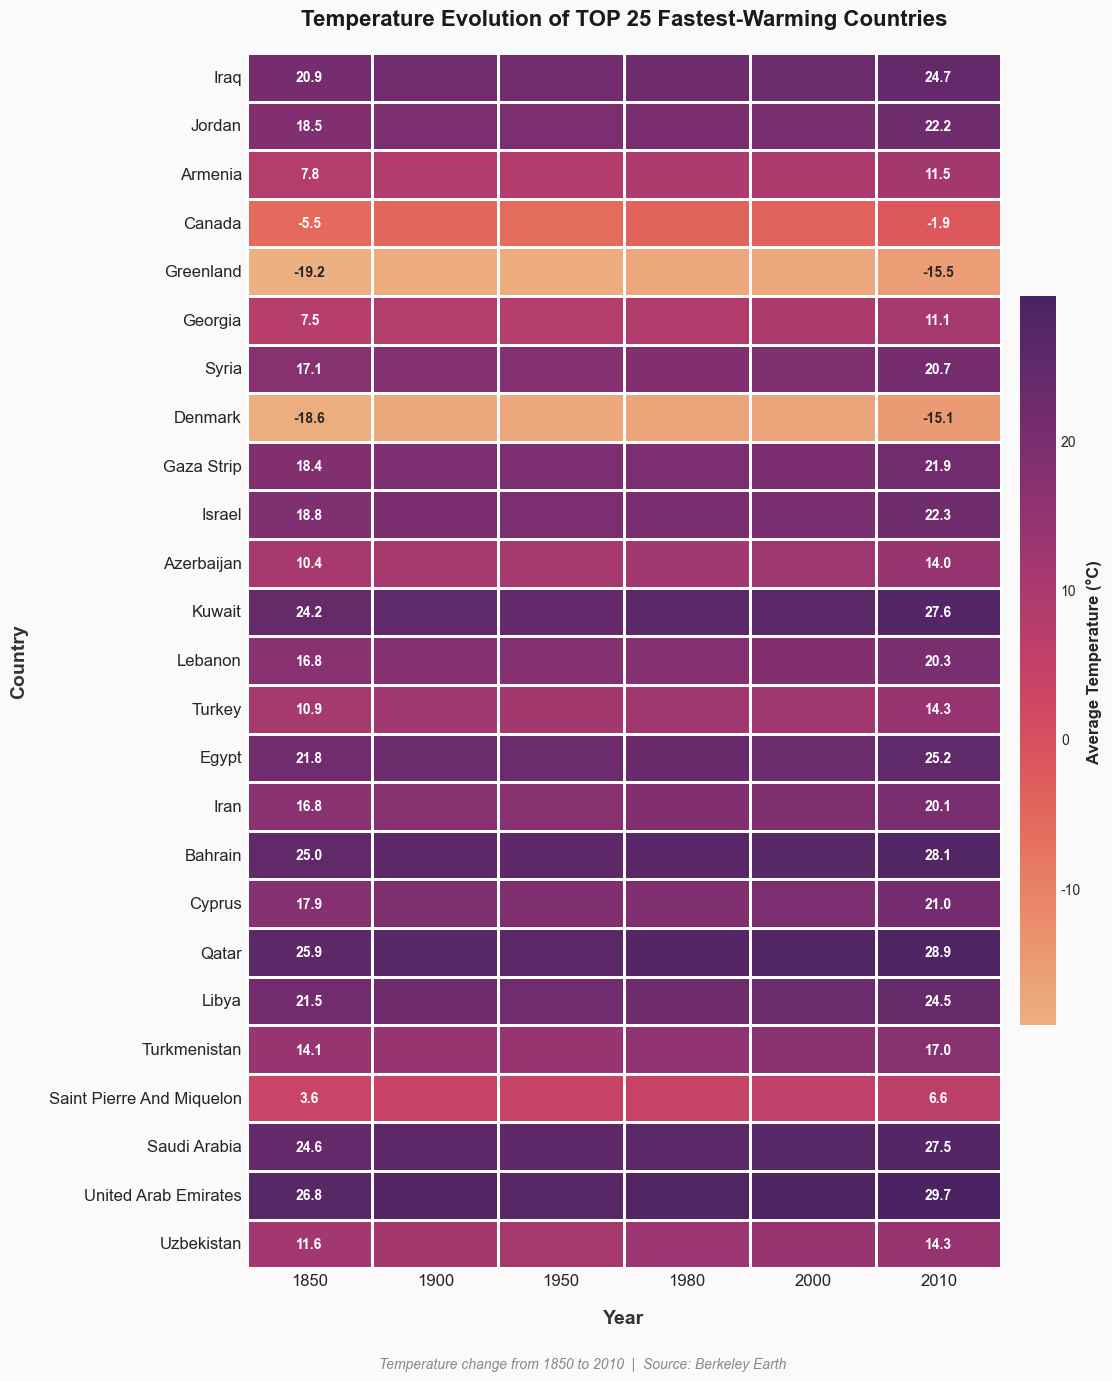

In [40]:
# Figure 3: Country Temperature Heatmap
print("📊 Plotting Figure 3: Country Temperature Heatmap...")

# Select key years for comparison
key_years = [1850, 1900, 1950, 1980, 2000, 2010]

# Aggregate by country and year
df_2010 = df_country[df_country['year'] == 2010].groupby('Country')['AverageTemperature'].mean().reset_index()
df_2010.columns = ['Country', 'temp_2010']

df_1850 = df_country[df_country['year'] == 1850].groupby('Country')['AverageTemperature'].mean().reset_index()
df_1850.columns = ['Country', 'temp_1850']

# Merge and calculate temperature change
df_change = df_2010.merge(df_1850, on='Country')
df_change['temp_change'] = df_change['temp_2010'] - df_change['temp_1850']

# Get TOP 25 countries with largest temperature increase
top_countries = df_change.nlargest(25, 'temp_change')['Country'].tolist()

# Prepare heatmap data
heatmap_data = []
for country in top_countries:
    temps = []
    for year in key_years:
        df_filtered = df_country[(df_country['Country'] == country) & 
                                (df_country['year'] == year)]
        if not df_filtered.empty:
            temps.append(df_filtered['AverageTemperature'].mean())
        else:
            temps.append(np.nan)
    heatmap_data.append(temps)

heatmap_df = pd.DataFrame(heatmap_data, index=top_countries, columns=key_years)

# Create custom annotation - only show 1850 and 2010
annot_df = heatmap_df.copy()
annot_df = annot_df.round(1).astype(str)
for col in [1900, 1950, 1980, 2000]:
    annot_df[col] = ''

# Create figure
fig, ax = plt.subplots(figsize=(12, 14))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Plot heatmap
sns.heatmap(heatmap_df, 
            cmap='flare',
            annot=annot_df,
            fmt='',
            annot_kws={'size': 10, 'weight': 'bold'},
            linewidths=2, 
            linecolor='white', 
            cbar_kws={'label': 'Average Temperature (°C)', 'shrink': 0.6, 'pad': 0.02},
            ax=ax,
            square=False)

# Style the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Average Temperature (°C)', fontsize=12, fontweight='bold')

# Set labels and title
ax.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333', labelpad=15)
ax.set_ylabel('Country', fontsize=14, fontweight='bold', color='#333333', labelpad=15)
ax.set_title('Temperature Evolution of TOP 25 Fastest-Warming Countries', 
             fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')

# Style tick labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight='medium')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight='medium')

# Add subtitle
fig.text(0.5, 0.01, 'Temperature change from 1850 to 2010  |  Source: Berkeley Earth', 
         fontsize=10, color='#888888', ha='center', style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / '02_country_heatmap_pro.png', dpi=300, bbox_inches='tight',
                facecolor='#FAFAFA', edgecolor='none')
    print("✓ Saved: 02_country_heatmap_pro.png")

📊 Plotting Figure 4: Temperature Change Rate...


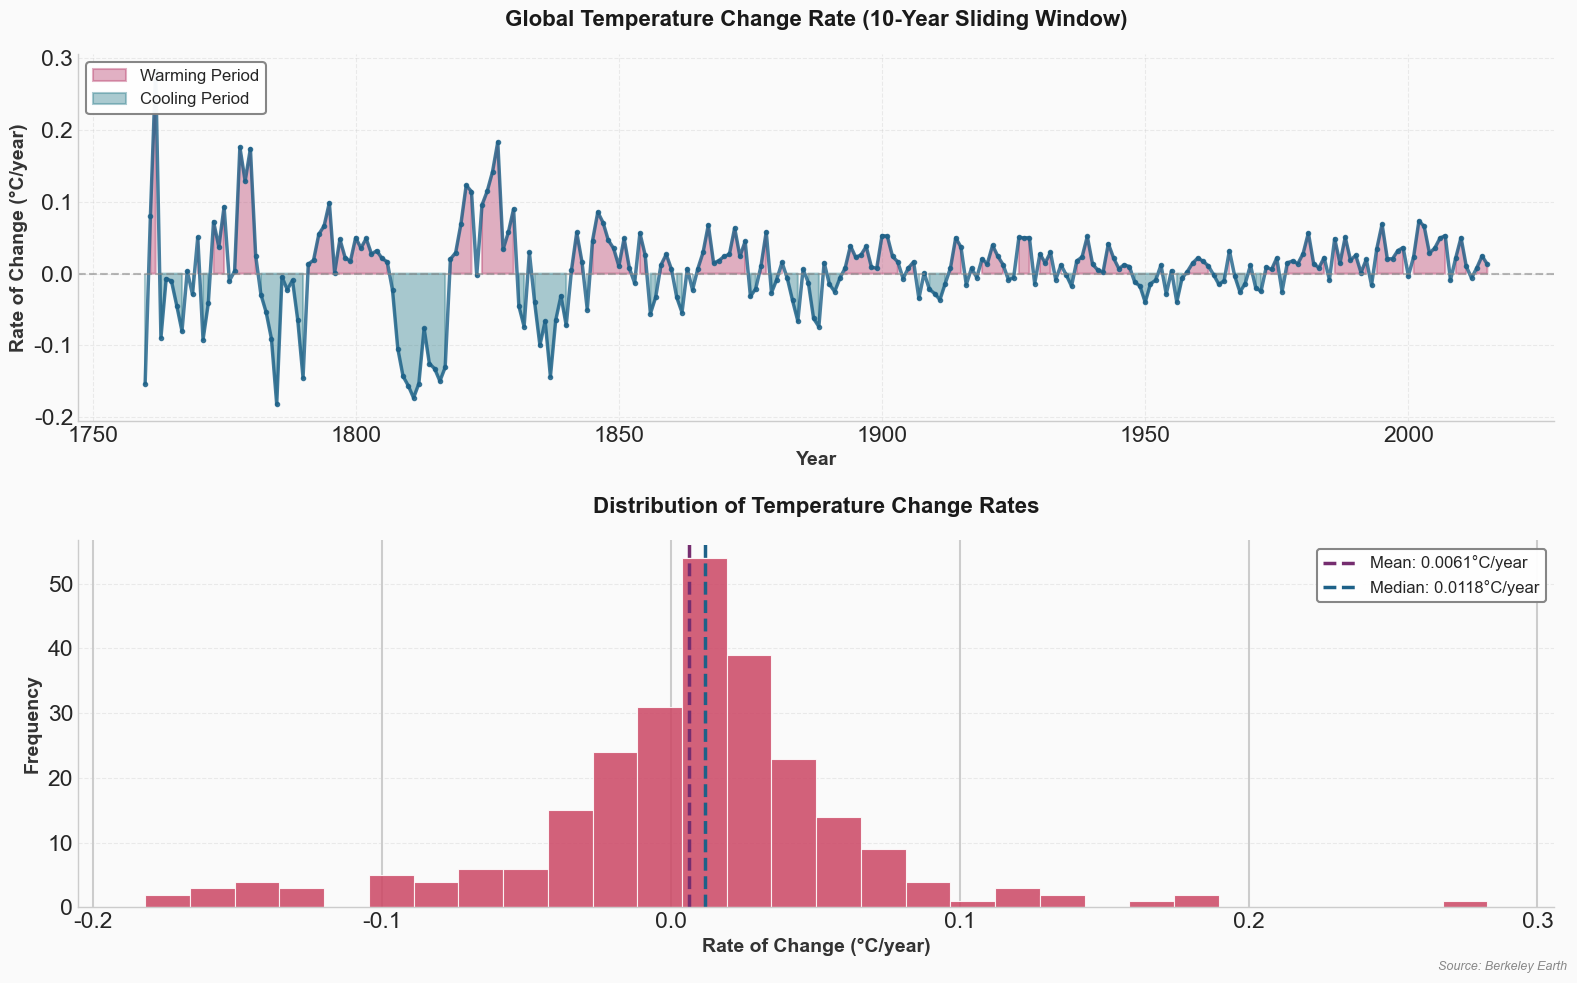


📈 Key Statistics:
   Mean change rate: 0.0061°C/year
   Median change rate: 0.0118°C/year
   Max warming rate: 0.2827°C/year
   Max cooling rate: -0.1820°C/year


In [41]:
# Figure 4: Temperature Change Rate
# Purpose: Answer "Is warming accelerating?" - Analyze the rate of temperature change
print("📊 Plotting Figure 4: Temperature Change Rate...")

# Calculate yearly average temperature
df_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
df_yearly = df_yearly.dropna()

# Calculate change rate using 10-year sliding window
window = 10
change_rates = []
years = []

for i in range(window, len(df_yearly)):
    start_temp = df_yearly.iloc[i-window]['LandAverageTemperature']
    end_temp = df_yearly.iloc[i]['LandAverageTemperature']
    rate = (end_temp - start_temp) / window  # °C/year
    change_rates.append(rate)
    years.append(df_yearly.iloc[i]['year'])

# Get color palettes
crest_colors = sns.color_palette("crest", n_colors=10)
flare_colors = sns.color_palette("flare", n_colors=10)

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#FAFAFA')

# ============ Subplot 1: Change Rate Time Series ============
ax1.set_facecolor('#FAFAFA')

# Main line - using crest palette
ax1.plot(years, change_rates, linewidth=2.5, color=crest_colors[7], 
         marker='o', markersize=3, alpha=0.8)

# Zero reference line
ax1.axhline(0, color='#888888', linestyle='--', linewidth=1.5, alpha=0.6)

# Fill areas - warming (flare/red) and cooling (crest/blue)
ax1.fill_between(years, 0, change_rates, 
                 where=np.array(change_rates) > 0,
                 alpha=0.4, color=flare_colors[5], label='Warming Period')
ax1.fill_between(years, 0, change_rates, 
                 where=np.array(change_rates) <= 0,
                 alpha=0.4, color=crest_colors[5], label='Cooling Period')

# Labels and title
ax1.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
ax1.set_ylabel('Rate of Change (°C/year)', fontsize=14, fontweight='bold', color='#333333')
ax1.set_title('Global Temperature Change Rate (10-Year Sliding Window)', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')

# Legend and grid
ax1.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, 
           edgecolor='gray', loc='upper left')
ax1.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ============ Subplot 2: Distribution Histogram ============
ax2.set_facecolor('#FAFAFA')

# Histogram - using flare palette
ax2.hist(change_rates, bins=30, color=flare_colors[4], edgecolor='white', 
         linewidth=0.8, alpha=0.85)

# Mean and median lines
mean_rate = np.mean(change_rates)
median_rate = np.median(change_rates)

ax2.axvline(mean_rate, color=flare_colors[8], linestyle='--', linewidth=2.5,
            label=f'Mean: {mean_rate:.4f}°C/year')
ax2.axvline(median_rate, color=crest_colors[7], linestyle='--', linewidth=2.5,
            label=f'Median: {median_rate:.4f}°C/year')

# Labels and title
ax2.set_xlabel('Rate of Change (°C/year)', fontsize=14, fontweight='bold', color='#333333')
ax2.set_ylabel('Frequency', fontsize=14, fontweight='bold', color='#333333')
ax2.set_title('Distribution of Temperature Change Rates', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')

# Legend and grid
ax2.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, 
           edgecolor='gray', loc='upper right')
ax2.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add data source
fig.text(0.99, 0.01, 'Source: Berkeley Earth', 
         fontsize=9, color='#888888', ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.show()

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / '06_temperature_change_rate.png', dpi=300, bbox_inches='tight',
                facecolor='#FAFAFA', edgecolor='none')
    print("✓ Saved: 06_temperature_change_rate.png")

print(f"\n📈 Key Statistics:")
print(f"   Mean change rate: {mean_rate:.4f}°C/year")
print(f"   Median change rate: {median_rate:.4f}°C/year")
print(f"   Max warming rate: {max(change_rates):.4f}°C/year")
print(f"   Max cooling rate: {min(change_rates):.4f}°C/year")

📊 绑制图5: 纬度带温度分布小提琴图...


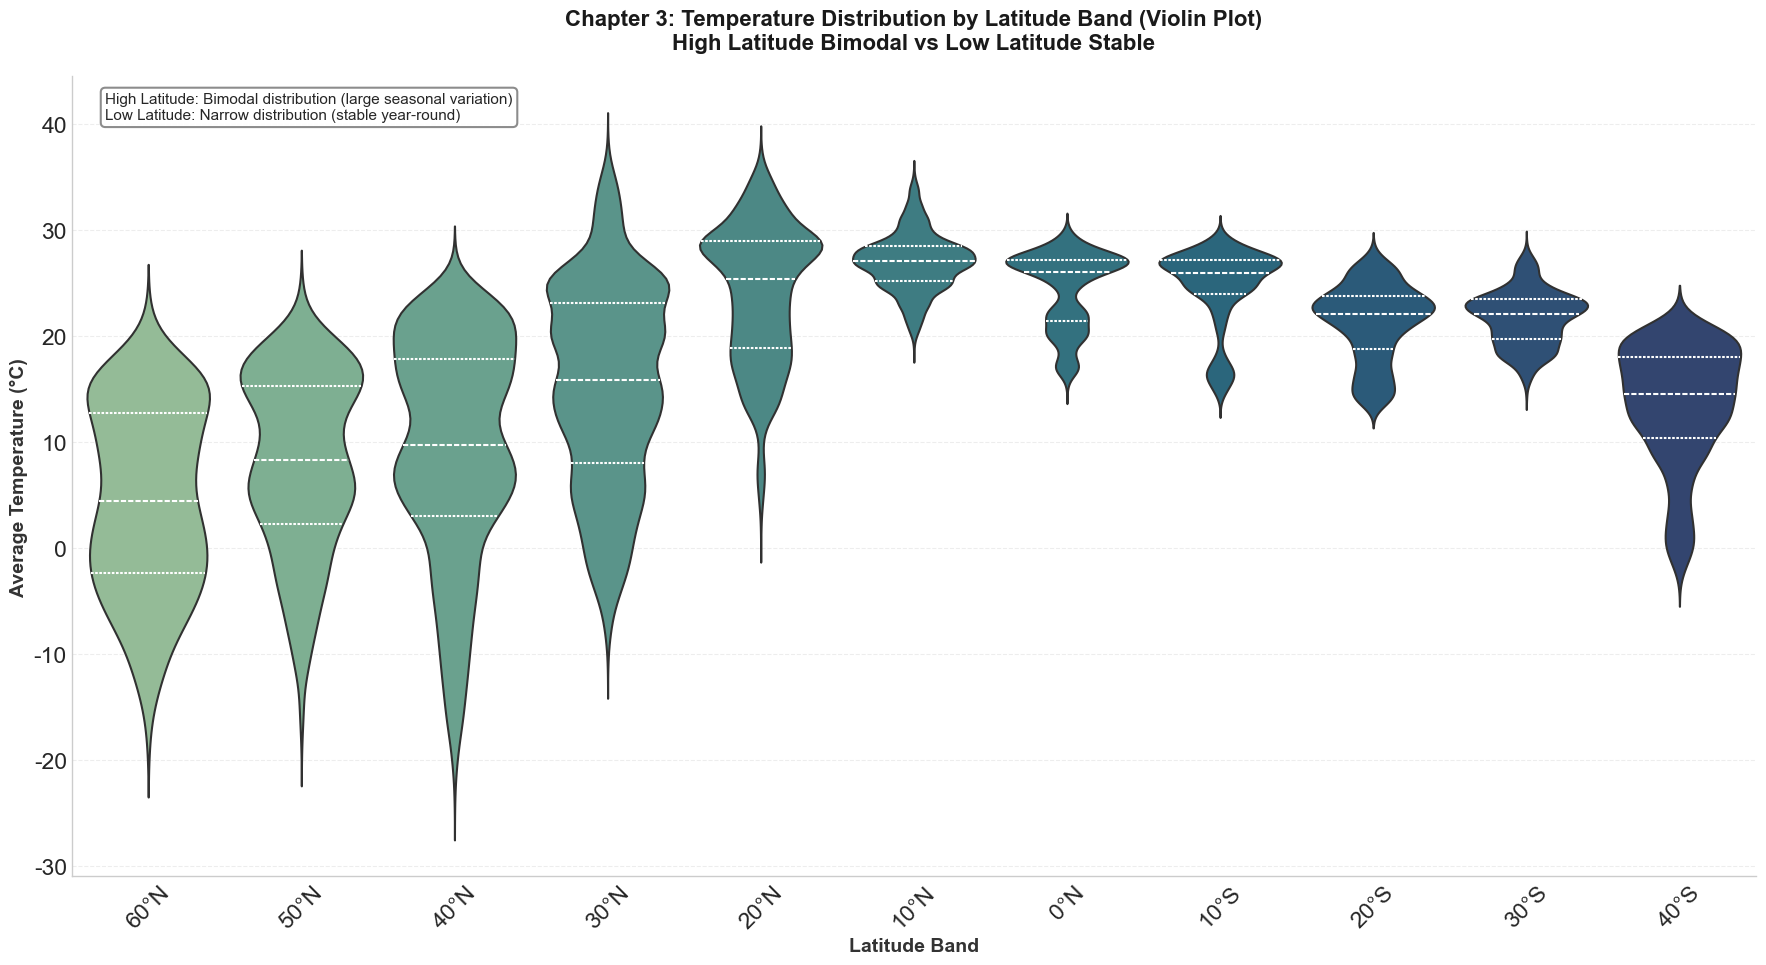

✓ Chart displayed (not saved)


In [48]:
# 图5: 纬度小提琴图 (04_latitude_violin.png)
print("📊 绑制图5: 纬度带温度分布小提琴图...")

# 过滤最近50年的数据
df_recent = df_city[df_city['year'] >= df_city['year'].max() - 50].copy()

# 创建纬度带（每10度一个区间）
def assign_latitude_band(lat):
    if pd.isna(lat):
        return None
    lat_rounded = int(lat // 10) * 10
    if lat >= 0:
        return f"{lat_rounded}°N"
    else:
        return f"{-lat_rounded}°S"

df_recent['latitude_band'] = df_recent['Latitude_num'].apply(assign_latitude_band)
df_recent = df_recent.dropna(subset=['latitude_band', 'AverageTemperature'])

# 按纬度排序
def parse_latitude_for_sort(lat_str):
    """解析纬度字符串用于排序"""
    if '°N' in lat_str:
        return float(lat_str.replace('°N', ''))
    elif '°S' in lat_str:
        return -float(lat_str.replace('°S', ''))
    return 0

latitude_order = sorted(df_recent['latitude_band'].unique(), 
                       key=parse_latitude_for_sort, 
                       reverse=True)

fig, ax = plt.subplots(figsize=(18, 10))

# 绘制小提琴图（使用 crest 配色 + 四分位线）
crest_colors = sns.color_palette("crest", n_colors=len(latitude_order))
sns.violinplot(data=df_recent, x='latitude_band', y='AverageTemperature',
              order=latitude_order,
              hue='latitude_band',
              hue_order=latitude_order,
              palette=crest_colors,
              inner='quartile', linewidth=1.5,
              legend=False,
              ax=ax)

# 四分位线改为白色
for l in ax.lines:
    l.set_color('white')
    l.set_linewidth(1.5)

# 英文标签和标题
ax.set_xlabel('Latitude Band', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('Chapter 3: Temperature Distribution by Latitude Band (Violin Plot)\nHigh Latitude Bimodal vs Low Latitude Stable',
            fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax.tick_params(axis='x', rotation=45)

# 英文注释
ax.text(0.02, 0.98, 'High Latitude: Bimodal distribution (large seasonal variation)\nLow Latitude: Narrow distribution (stable year-round)', 
       transform=ax.transAxes, fontsize=11, va='top', ha='left',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# 美化
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '04_latitude_violin.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 04_latitude_violin.png")
else:
    print("✓ Chart displayed (not saved)")

📊 Plotting Figure 6: Hemisphere Temperature Distribution Comparison...
Available Northern Hemisphere countries: 25
Available Southern Hemisphere countries: 15

Selected Northern countries: ['China', 'United States', 'Norway', 'Germany', 'Russia']
Selected Southern countries: ['Zambia', 'Chile', 'South Africa', 'Bolivia', 'Argentina']

Latest year in data: 2013
Period 1 (Earlier): 1913 - 1963
Period 2 (Recent): 1963 - 2013


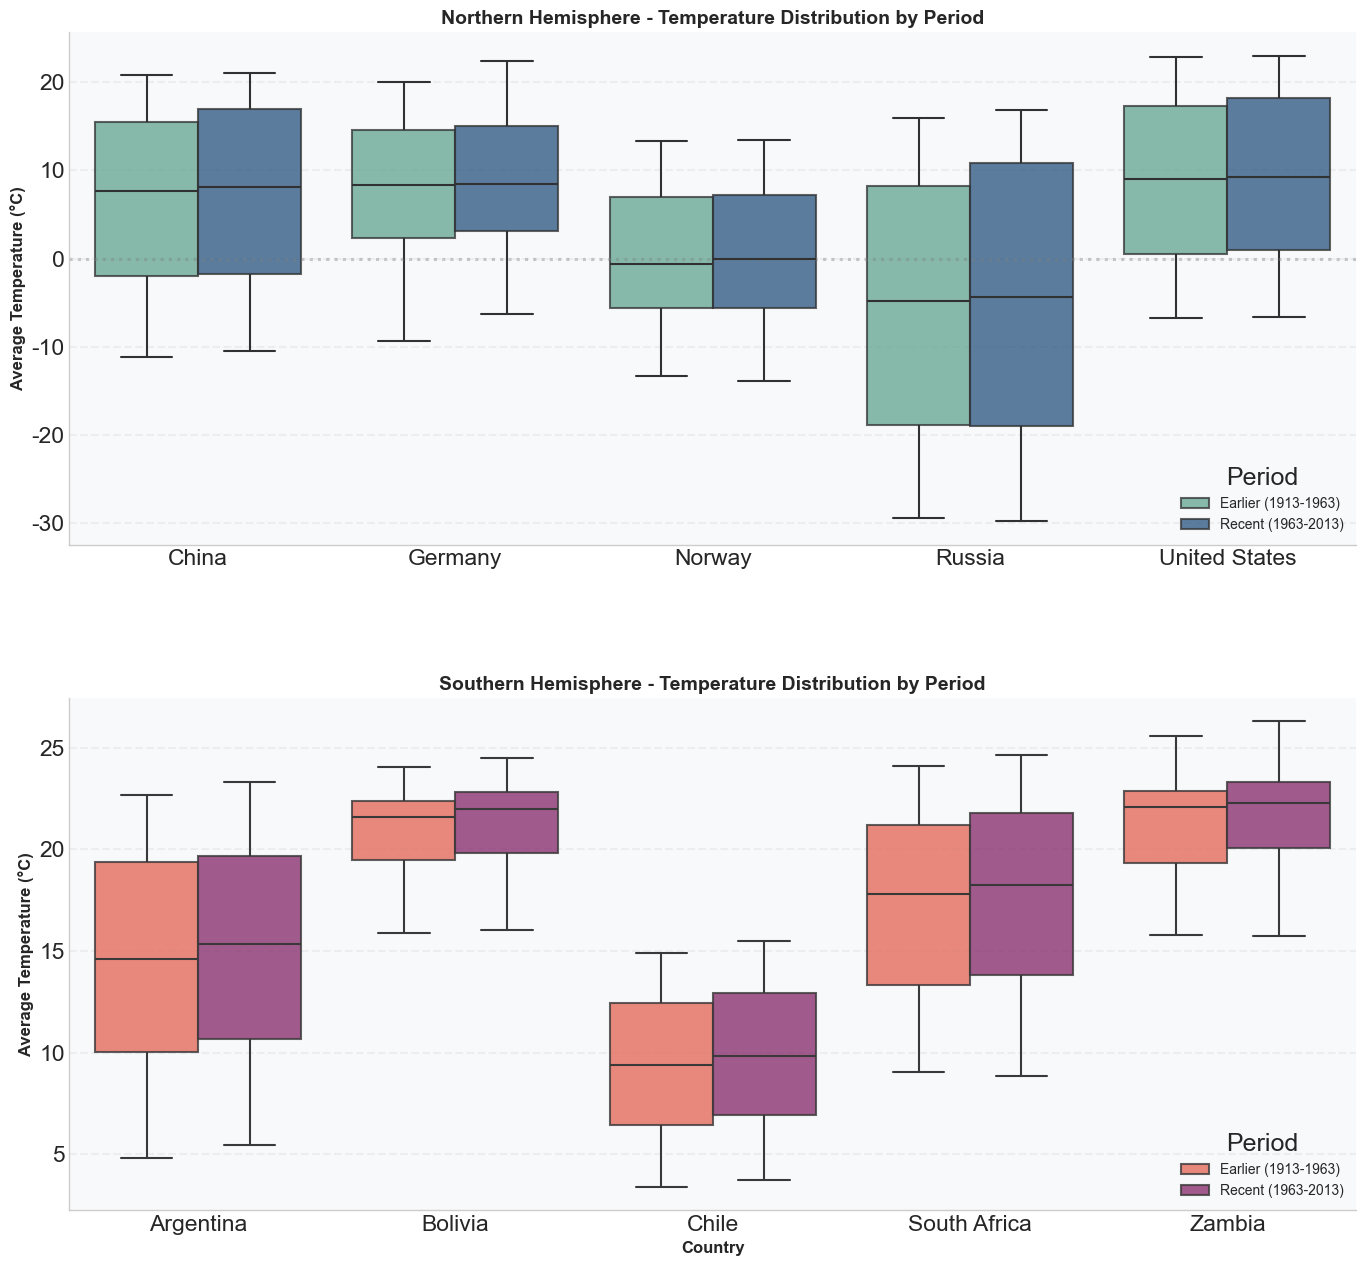


📈 Statistical Analysis

【Northern Hemisphere】
  Earlier (1913-1963):
    - Mean Temp:   3.76°C
    - Median:      4.53°C
    - Max Temp:    22.83°C
    - Std Dev:     11.28°C
  Recent (1963-2013):
    - Mean Temp:   4.22°C
    - Median:      5.09°C
    - Max Temp:    23.01°C
    - Std Dev:     11.19°C

【Southern Hemisphere】
  Earlier (1913-1963):
    - Mean Temp:   16.71°C
    - Median:      18.24°C
    - Max Temp:    25.56°C
    - Std Dev:     5.62°C
  Recent (1963-2013):
    - Mean Temp:   17.13°C
    - Median:      18.70°C
    - Max Temp:    26.28°C
    - Std Dev:     5.61°C

🔥 Temperature Change Trends

【Northern Hemisphere】
  Mean Temp Change:    +0.46°C
  Extreme Heat Change: +0.17°C

【Southern Hemisphere】
  Mean Temp Change:    +0.42°C
  Extreme Heat Change: +0.72°C

✓ Chart displayed successfully!


  【图表描述】

该图表展示了南北半球主要国家在不同历史时期的温度分布变化，分为两个子图：

1. 北半球温度分布图（上图）：
   - 展示中国、美国等5个北半球国家在两个时期的温度分布
   - 箱体显示温度的四分位数范围，中线为中位数
   - Earlier期（浅蓝绿）与Recent期（深蓝）形成对比
   - 可观察各国温度分布的变化趋势及极端值

In [8]:
# Figure 6: Temperature Distribution Boxplot - Hemisphere Comparison
# Comparing temperature distribution changes between different periods in both hemispheres
print("📊 Plotting Figure 6: Hemisphere Temperature Distribution Comparison...")

import random
random.seed(42)

# ===== 1. Define countries by hemisphere =====
northern_hemisphere_countries = [
    'China', 'United States', 'Russia', 'Canada', 'India', 
    'Germany', 'France', 'Japan', 'United Kingdom', 'Italy',
    'Spain', 'Mexico', 'Turkey', 'Iran', 'Thailand',
    'Vietnam', 'South Korea', 'Poland', 'Ukraine', 'Netherlands',
    'Belgium', 'Sweden', 'Norway', 'Finland', 'Denmark'
]

southern_hemisphere_countries = [
    'Australia', 'Brazil', 'Argentina', 'South Africa', 'Chile',
    'New Zealand', 'Peru', 'Indonesia', 'Madagascar', 'Mozambique',
    'Zimbabwe', 'Zambia', 'Bolivia', 'Paraguay', 'Uruguay'
]

# ===== 2. Filter available countries =====
available_countries = df_country['Country'].unique()
north_available = [c for c in northern_hemisphere_countries if c in available_countries]
south_available = [c for c in southern_hemisphere_countries if c in available_countries]

print(f"Available Northern Hemisphere countries: {len(north_available)}")
print(f"Available Southern Hemisphere countries: {len(south_available)}")

# ===== 3. Sample selection =====
# North: must include China and USA, plus 3 random
required_north = ['China', 'United States']
other_north = [c for c in north_available if c not in required_north]
random_north = random.sample(other_north, min(3, len(other_north)))
selected_north = required_north + random_north

# South: 5 random countries
selected_south = random.sample(south_available, min(5, len(south_available)))

print(f"\nSelected Northern countries: {selected_north}")
print(f"Selected Southern countries: {selected_south}")

# ===== 4. Define time periods =====
max_year = df_country['year'].max()
print(f"\nLatest year in data: {max_year}")

period1_start = max_year - 100
period1_end = max_year - 50
period2_start = max_year - 50
period2_end = max_year

print(f"Period 1 (Earlier): {period1_start} - {period1_end}")
print(f"Period 2 (Recent): {period2_start} - {period2_end}")

# ===== 5. Prepare data =====
df_north = df_country[
    (df_country['Country'].isin(selected_north)) &
    (df_country['year'] >= period1_start) &
    (df_country['year'] <= period2_end)
].copy()
df_north['Hemisphere'] = 'Northern'

df_south = df_country[
    (df_country['Country'].isin(selected_south)) &
    (df_country['year'] >= period1_start) &
    (df_country['year'] <= period2_end)
].copy()
df_south['Hemisphere'] = 'Southern'

df_combined = pd.concat([df_north, df_south], ignore_index=True)

# Add period labels
df_combined['Period'] = df_combined['year'].apply(
    lambda x: f'Earlier ({period1_start}-{period1_end})' if x <= period1_end 
              else f'Recent ({period2_start}-{period2_end})'
)

# Color palette
period_palette = {
    f'Earlier ({period1_start}-{period1_end})': '#3498db',
    f'Recent ({period2_start}-{period2_end})': '#e74c3c'
}

# ===== 6. Create visualization =====

crest_colors = sns.color_palette("crest", n_colors=10)
flare_colors = sns.color_palette("flare", n_colors=10)

north_palette = {
    f'Earlier ({period1_start}-{period1_end})': crest_colors[2],
    f'Recent ({period2_start}-{period2_end})': crest_colors[8]
}

south_palette = {
    f'Earlier ({period1_start}-{period1_end})': flare_colors[2],
    f'Recent ({period2_start}-{period2_end})': flare_colors[7]
}

fig, axes = plt.subplots(2, 1, figsize=(14, 13))

# --- Northern Hemisphere ---
ax1 = axes[0]
df_north_plot = df_combined[df_combined['Hemisphere'] == 'Northern']

box1 = sns.boxplot(
    data=df_north_plot, 
    x='Country', 
    y='AverageTemperature',
    hue='Period',
    palette=north_palette,
    ax=ax1,
    showfliers=True,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
    linewidth=1.5,
    saturation=0.90  # 稍微降低饱和度
)

# 设置箱体透明度
for patch in ax1.patches:
    patch.set_alpha(0.75)

ax1.set_xlabel('')
ax1.set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
ax1.set_title('Northern Hemisphere - Temperature Distribution by Period', fontsize=14, fontweight='bold')
ax1.legend(title='Period', loc='lower right', fontsize=10, framealpha=0.9)
ax1.grid(axis='y', alpha=0.25, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('#f8f9fa')
ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.4)

# --- Southern Hemisphere ---
ax2 = axes[1]
df_south_plot = df_combined[df_combined['Hemisphere'] == 'Southern']

box2 = sns.boxplot(
    data=df_south_plot, 
    x='Country', 
    y='AverageTemperature',
    hue='Period',
    palette=south_palette,
    ax=ax2,
    showfliers=True,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
    linewidth=1.5,
    saturation=1.00
)

# 设置箱体透明度
for patch in ax2.patches:
    patch.set_alpha(0.80)

ax2.set_xlabel('Country', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
ax2.set_title('Southern Hemisphere - Temperature Distribution by Period', fontsize=14, fontweight='bold')
ax2.legend(title='Period', loc='lower right', fontsize=10, framealpha=0.9)
ax2.grid(axis='y', alpha=0.25, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()
# ===== 7. Statistical Analysis =====
print("\n" + "="*60)
print("📈 Statistical Analysis")
print("="*60)

for hemisphere in ['Northern', 'Southern']:
    print(f"\n【{hemisphere} Hemisphere】")
    df_h = df_combined[df_combined['Hemisphere'] == hemisphere]
    
    for period in df_combined['Period'].unique():
        df_p = df_h[df_h['Period'] == period]
        print(f"  {period}:")
        print(f"    - Mean Temp:   {df_p['AverageTemperature'].mean():.2f}°C")
        print(f"    - Median:      {df_p['AverageTemperature'].median():.2f}°C")
        print(f"    - Max Temp:    {df_p['AverageTemperature'].max():.2f}°C")
        print(f"    - Std Dev:     {df_p['AverageTemperature'].std():.2f}°C")

print("\n" + "="*60)
print("🔥 Temperature Change Trends")
print("="*60)

for hemisphere in ['Northern', 'Southern']:
    df_h = df_combined[df_combined['Hemisphere'] == hemisphere]
    period1_label = f'Earlier ({period1_start}-{period1_end})'
    period2_label = f'Recent ({period2_start}-{period2_end})'
    
    mean1 = df_h[df_h['Period'] == period1_label]['AverageTemperature'].mean()
    mean2 = df_h[df_h['Period'] == period2_label]['AverageTemperature'].mean()
    change = mean2 - mean1
    
    max1 = df_h[df_h['Period'] == period1_label]['AverageTemperature'].max()
    max2 = df_h[df_h['Period'] == period2_label]['AverageTemperature'].max()
    max_change = max2 - max1
    
    print(f"\n【{hemisphere} Hemisphere】")
    print(f"  Mean Temp Change:    {change:+.2f}°C")
    print(f"  Extreme Heat Change: {max_change:+.2f}°C")

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / '05_temperature_distribution.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: 05_temperature_distribution.png")
else:
    print("\n✓ Chart displayed successfully!")

# ===== 8. 图表说明 =====
print("\n")
print("=" * 80)
print("  【图表描述】")
print("=" * 80)
print("""
该图表展示了南北半球主要国家在不同历史时期的温度分布变化，分为两个子图：

1. 北半球温度分布图（上图）：
   - 展示中国、美国等5个北半球国家在两个时期的温度分布
   - 箱体显示温度的四分位数范围，中线为中位数
   - Earlier期（浅蓝绿）与Recent期（深蓝）形成对比
   - 可观察各国温度分布的变化趋势及极端值变化

2. 南半球温度分布图（下图）：
   - 展示5个南半球国家在两个时期的温度分布
   - Earlier期（浅橙）与Recent期（红色）形成对比
   - 可对比南北半球气候变化的差异性

【可视化方式】
- 颜色主题：北半球采用crest（蓝-青）冷色系，南半球采用flare（橙-红）暖色系
  * Earlier期：使用调色板中的浅色，表示历史早期
  * Recent期：使用调色板中的深色，表示近期变化
- 透明度设置：箱体透明度75%，增加图表层次感
- 异常值标记：显示极端温度点，便于识别气候极端事件

【分析要点】
- 比较同一国家两个时期的箱体位置变化，评估温度上升趋势
- 观察箱体的高度变化，评估温度波动性变化
- 关注异常值点的分布，识别极端高温事件的频率变化
- 对比南北半球的整体趋势，分析气候变化的空间非对称性

*注：该分析用于探讨极端高温风险是否在近代显著强化，以及这一过程在不同半球之间是否呈现非对称性。
数据来源：Berkeley Earth 全球温度数据集。*
""")

📊 Plotting Figure 7: Decade Comparison Analysis...


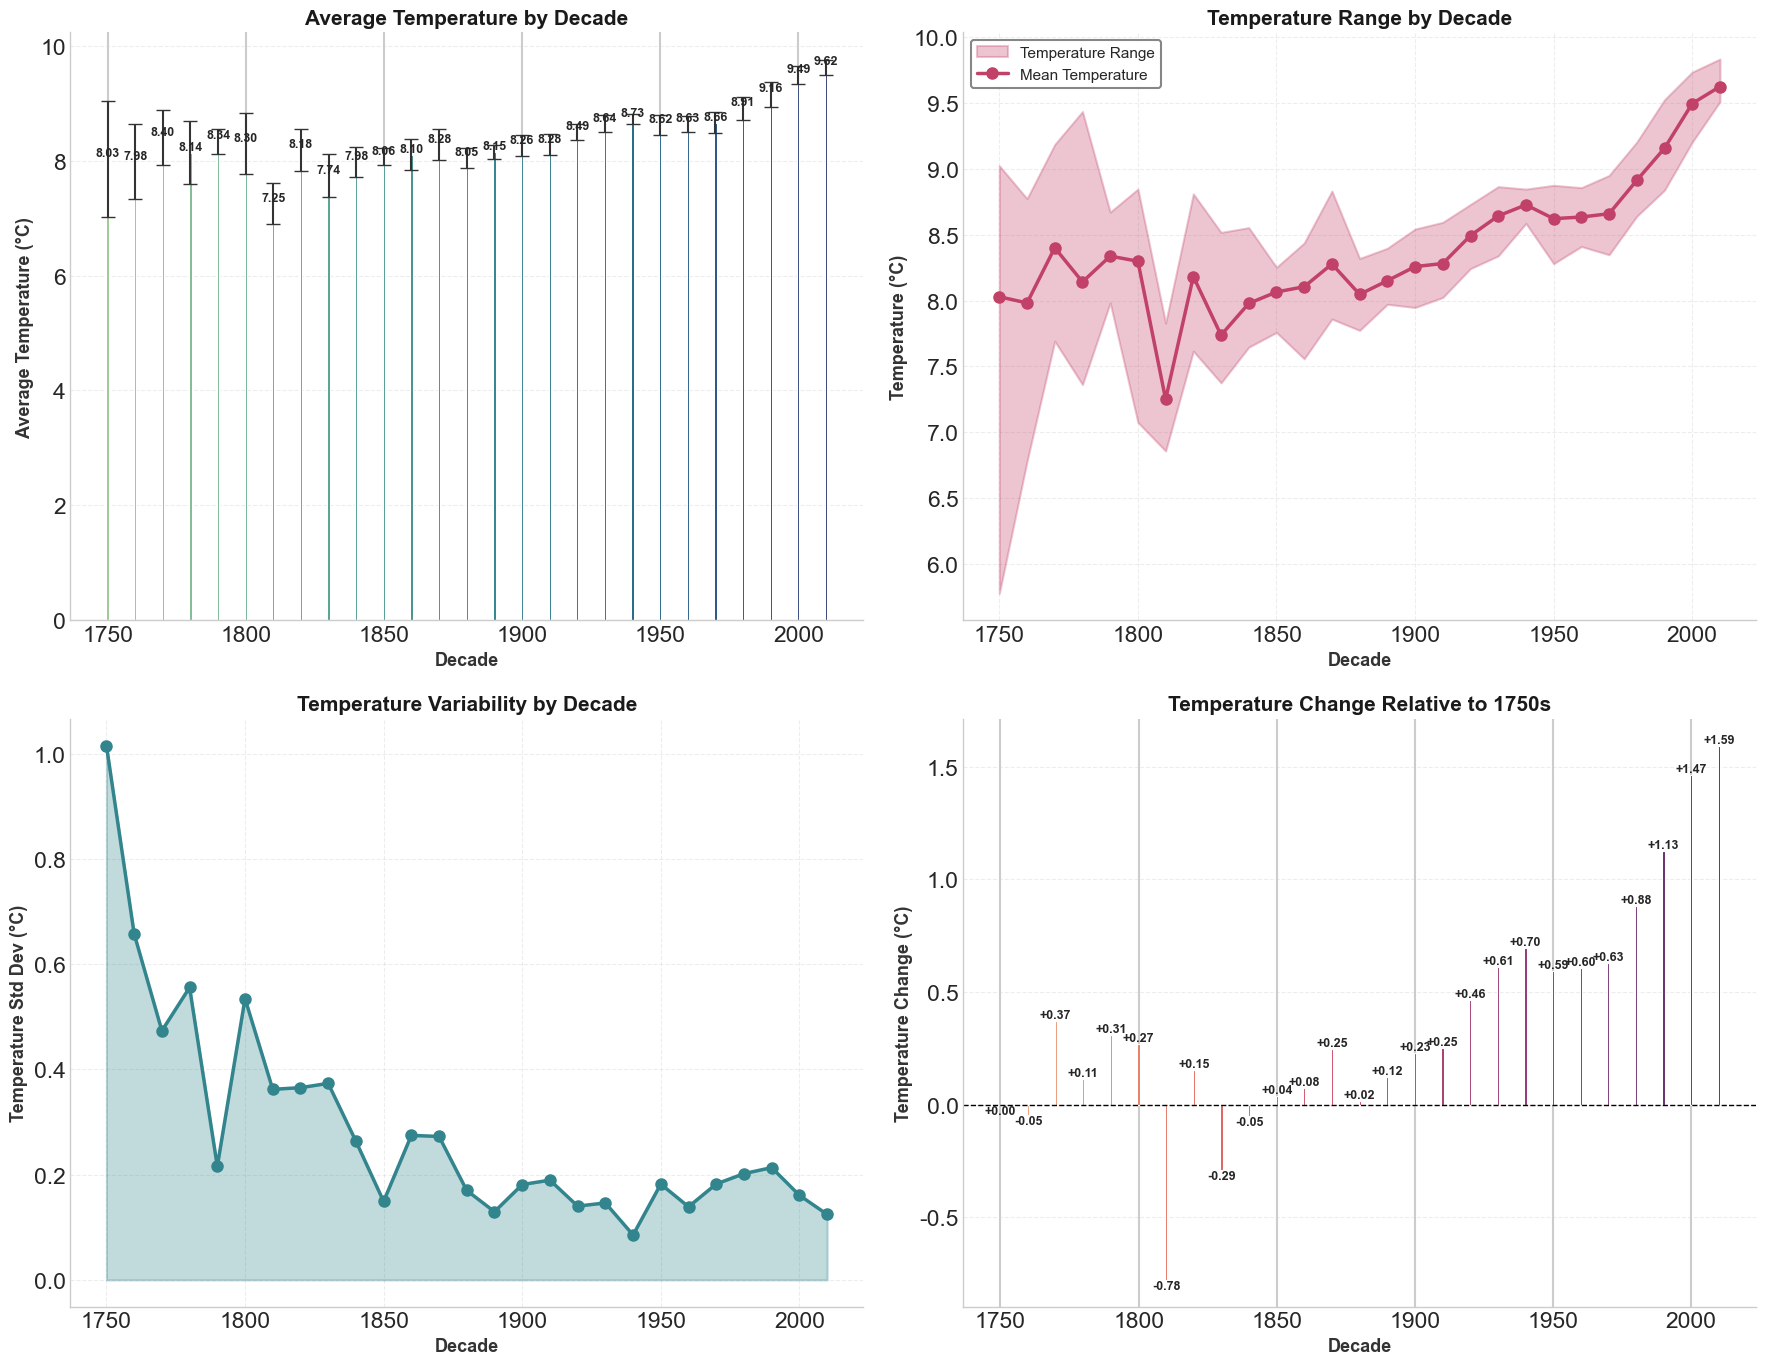

✓ Chart displayed (not saved)


In [49]:
# 图7: 年代对比分析 (12_decade_comparison.png)
print("📊 Plotting Figure 7: Decade Comparison Analysis...")

# 按年份聚合
df_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
df_yearly = df_yearly.dropna()

# 按年代分组
df_yearly['decade'] = (df_yearly['year'] // 10) * 10
df_decade = df_yearly.groupby('decade')['LandAverageTemperature'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 配色方案
crest_colors = sns.color_palette("crest", len(df_decade))
flare_colors = sns.color_palette("flare", len(df_decade))

# 子图1：年代平均温度 (使用 crest)
bars1 = ax1.bar(df_decade['decade'], df_decade['mean'],
               color=crest_colors, edgecolor='white', linewidth=0.8)
ax1.errorbar(df_decade['decade'], df_decade['mean'], yerr=df_decade['std'],
             fmt='none', color='#333333', capsize=5, linewidth=1.5)

ax1.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax1.set_ylabel('Average Temperature (°C)', fontsize=13, fontweight='bold', color='#333333')
ax1.set_title('Average Temperature by Decade', fontsize=15, fontweight='bold', color='#1a1a1a')
ax1.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 添加数值标签
for bar, mean_val in zip(bars1, df_decade['mean']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean_val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 子图2：温度范围 (使用 flare)
ax2.fill_between(df_decade['decade'], df_decade['min'], df_decade['max'],
                alpha=0.3, color=flare_colors[len(flare_colors)//2], label='Temperature Range')
ax2.plot(df_decade['decade'], df_decade['mean'], 'o-', linewidth=2.5,
        color=flare_colors[len(flare_colors)//2], markersize=8, label='Mean Temperature')

ax2.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax2.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold', color='#333333')
ax2.set_title('Temperature Range by Decade', fontsize=15, fontweight='bold', color='#1a1a1a')
ax2.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax2.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 子图3：温度标准差 (使用 crest)
ax3.plot(df_decade['decade'], df_decade['std'], 'o-', linewidth=2.5,
        color=crest_colors[len(crest_colors)//2], markersize=8)
ax3.fill_between(df_decade['decade'], 0, df_decade['std'],
                alpha=0.3, color=crest_colors[len(crest_colors)//2])

ax3.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax3.set_ylabel('Temperature Std Dev (°C)', fontsize=13, fontweight='bold', color='#333333')
ax3.set_title('Temperature Variability by Decade', fontsize=15, fontweight='bold', color='#1a1a1a')
ax3.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 子图4：温度变化趋势 (使用 flare)
first_decade_temp = df_decade.iloc[0]['mean']
df_decade['change_from_first'] = df_decade['mean'] - first_decade_temp

bars4 = ax4.bar(df_decade['decade'], df_decade['change_from_first'],
               color=flare_colors, edgecolor='white', linewidth=0.8)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)

ax4.set_xlabel('Decade', fontsize=13, fontweight='bold', color='#333333')
ax4.set_ylabel('Temperature Change (°C)', fontsize=13, fontweight='bold', color='#333333')
ax4.set_title(f'Temperature Change Relative to {int(df_decade.iloc[0]["decade"])}s', 
             fontsize=15, fontweight='bold', color='#1a1a1a')
ax4.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# 添加数值标签
for bar, change in zip(bars4, df_decade['change_from_first']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{change:+.2f}', ha='center', 
            va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=9)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '12_decade_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 12_decade_comparison.png")
else:
    print("✓ Chart displayed (not saved)")

In [10]:
# 完成总结
print("\n" + "="*60)
print("✅ 所有图表复现完成！")
print("="*60)

if SAVE_FIGURES:
    print(f"\n📁 输出目录: {OUTPUT_DIR}")
    print("\n生成的图表:")
    print("  1. 01_global_temperature_trend.png - 全球温度趋势")
    print("  2. 01_temperature_bands.png - 温度带图")
    print("  3. 02_country_heatmap_pro.png - 国家热力图")
    print("  4. 06_temperature_change_rate.png - 温度变化速率")
    print("  5. 04_latitude_violin.png - 纬度小提琴图")
    print("  6. 05_temperature_distribution.png - 温度分布")
    print("  7. 12_decade_comparison.png - 年代对比")
else:
    print("\n💡 提示：所有图表已在notebook中显示")
    print("   如需保存，请将第一个cell中的 SAVE_FIGURES 设为 True")
    print("   然后重新运行相应的cell")

print("\n" + "="*60)



✅ 所有图表复现完成！

💡 提示：所有图表已在notebook中显示
   如需保存，请将第一个cell中的 SAVE_FIGURES 设为 True
   然后重新运行相应的cell

